In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from ase.io.trajectory import Trajectory
from flonacomldft.collective_variables import get_collective_variables
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from flonacomldft.utils.diagnostics import R_hat

size=7
params = {'legend.fontsize': size,
          'figure.figsize': (7, 2.5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [2]:
path_database = '/mnt/home/amolina/ceph/adaptive-flow-mc/database/andersen/'
md_files = ['trajectories/27037382_is0_andersen.traj',  'trajectories/27037385_is1_andersen.traj']

trajs = {i: Trajectory(path_database + md_files[i])[200:] for i in range(len(md_files))}

In [3]:
len(trajs[0]), len(trajs[1])

(9801, 9801)

In [4]:
temperature = {i: np.array([molecule.get_temperature() for molecule in trajs[i]]) for i in trajs.keys()}

In [5]:
from flonacomldft.utils.io_utils import save_ase_molecules_as_traj

In [6]:
trajs = {i: trajs[i][::10] for i in range(len(md_files))}

In [9]:
len(trajs[0][:50])


50

In [10]:
len(trajs[1][:50])

50

In [ ]:
save_ase_molecules_as_traj(trajs[0][:100], 'is0_md.traj')
save_ase_molecules_as_traj(trajs[1][:100], 'is1_md.traj')

In [23]:
import matplotlib.pyplot as plt

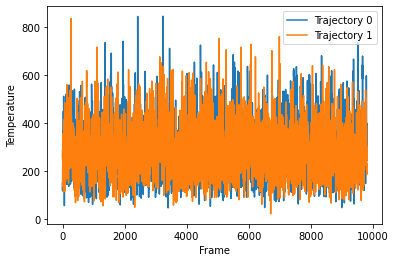

In [26]:
plt.plot(temperature[0], label='Trajectory 0')
plt.plot(temperature[1], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Temperature')
plt.legend()
plt.show()


In [35]:
u = {i: np.array([molecule.get_potential_energy() for molecule in trajs[i]]) for i in trajs.keys()}

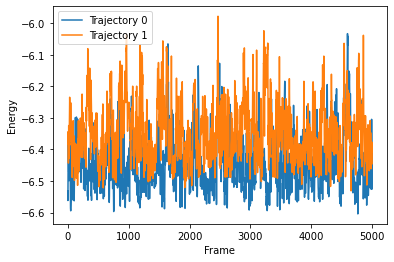

In [36]:
plt.plot(u[0][100:5100], label='Trajectory 0')
plt.plot(u[1][100:5100], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Energy')
plt.legend()
plt.show()


In [6]:
cv = {i: np.stack([get_collective_variables(molecule) for molecule in trajs[i][:5]]) for i in trajs.keys()}

In [12]:
import torch
from flonacomldft.internal_coordinates import Coordinates_mapping

In [13]:
from flonacomldft.internal_coordinates import save_internal_coordinates_to_csv

In [14]:
coord_mapping = Coordinates_mapping()
dim = 12
isomer_label = 0

In [15]:
zmats = coord_mapping.get_internal_from_trajectory(trajectory=trajs[isomer_label][:5], 
                                            isomer=isomer_label,
                                            temperature=350, 
                                            add_potential_energy=True,
                                            add_cvs=True,)

In [28]:
'27037382_is0_andersen.traj'.split('/')[-1].split('.')[0]+ '_zmats' + '.csv'

'27037382_is0_andersen_zmats.csv'

In [17]:
from flonacomldft.utils.silver_isomers_utils import get_construction_table
construction_table = get_construction_table()
save_internal_coordinates_to_csv(zmats, 
                                construction_table=construction_table, 
                                filename='internal_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [19]:
coord_xs, logdetjac_xs, energies_xs = coord_mapping.get_real_centered_from_internal(zmats[:, :dim], 
                                                    isomer=isomer_label, 
                                                    temperature=350,
                                                    energies=zmats[:, dim],
                                                    logdetjacs=zmats[:, dim+2])

In [20]:
xs = torch.cat([coord_xs, 
                energies_xs.reshape(-1, 1),
                torch.ones(coord_xs.shape[0]).reshape(-1, 1)*isomer_label,
                logdetjac_xs.reshape(-1, 1),
                zmats[:, -2:]], dim=1)

In [22]:
columns = ['rc{:d}' for i in range(dim)]
save_internal_coordinates_to_csv( xs, 
                                columns=columns, 
                                filename='real_centered_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [29]:
from flonacomldft.utils.io_utils import get_path, load_pickle_file
import torch

In [30]:
flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]
mlp_model = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]

In [31]:
from flonacomldft.models.mixture import Mixture

flow_model = Mixture(flow_models, torch.tensor([0.5, 0.5]))

In [32]:
n_chains = 10
n_steps = 20
xs_init = flow_model.sample(n_chains)
us_init = mlp_model[0](xs_init)
isomers_init = torch.zeros(n_chains, 1)

init = torch.cat([xs_init, us_init, isomers_init], dim=1)

In [5]:
from flonacomldft.sampling import run_metropolis

In [34]:
mh = run_metropolis(model = flow_model, 
                init = init, 
                n_chains = n_chains,
                n_steps = n_steps,
                id_run = 'N/A', 
                energy_type = 'mlp', 
                temperature = 350,
                mixture = True,
                mlp_models = mlp_model,
                frac_computed = 0.2,
                dim = 12,
                update_weights = True,
                scheduler_weights = 5,
                alpha = 0.5,
                return_ratios = False,
                return_proposals = True,
                with_tqdm = False,
                folder_name = None,
                )

Running Metropolis-Hastings
Number of chains: 10
Number of steps: 20
Temperature: 350K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.800 		 0.300
1 	 0.500 		 0.200
2 	 0.500 		 0.100
3 	 0.300 		 0.000
4 	 0.300 		 0.000
5 	 0.400 		 0.000
6 	 0.300 		 0.000
7 	 0.100 		 0.000
8 	 0.200 		 0.000
9 	 0.300 		 0.000
10 	 0.100 		 0.000
11 	 0.200 		 0.000
12 	 0.400 		 0.000
13 	 0.400 		 0.000
14 	 0.300 		 0.000
15 	 0.200 		 0.000
16 	 0.200 		 0.000
17 	 0.300 		 0.000
18 	 0.400 		 0.000
19 	 0.100 		 0.000


In [35]:
from flonacomldft.utils.io_utils import load_csv_file
from flonacomldft.train_flow_from_data import train_flow
from flonacomldft.train_mlp_from_data import train_mlp

In [36]:
#flow_train = [load_csv_file('is'+str(i)+'_flow_train.csv', get_path() + '/andersen/datasets')[:, :14]
#              for i in range(2)]
#flow_test = [load_csv_file('is'+str(i)+'_flow_test.csv', get_path() + '/andersen/datasets')[:, :14]
#                for i in range(2)]

from flonacomldft.utils.data_processing import load_datasets

flow_train = []
flow_test = []

isomer_labels = [0, 1]

for isomer_label in isomer_labels:
    
    dataset = load_datasets('andersen', isomer_label, name='flow', real_centered=True)
    flow_train.append(dataset['train'].clone())
    flow_test.append(dataset['test'].clone())

    del dataset

In [37]:
dict_flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]
dict_mlp_models = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]

In [38]:
n_runs = 5
n_chains = 10
n_steps = 5

flow_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_scheduler': 10,
    'save_splits': 1,
    'grad_clip': 1e4,
    }

mlp_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_schedule': 100,
    'save_splits': 1,
    }

In [39]:
from flonacomldft.full_adaptive_sampling import run_adaptive_sampling

In [40]:
adaptive_sampling = run_adaptive_sampling(mcmc_init=init, 
                n_chains=n_chains,
                n_steps=n_steps,
                n_runs=n_runs,
                flow_init_train=flow_train,
                flow_init_test=flow_test,
                dict_flows_init=dict_flow_models,
                flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                energy_type='emt-mlp',
                temperature=350,
                mixture=True,
                dim=12,
                dict_mlps_init=dict_mlp_models,
                mlp_init_train=flow_train,
                mlp_init_test=flow_test,
                mlp_hyperparams=[mlp_hyperparams, mlp_hyperparams],
                train_mlp_models=True,
                frac_computed=0.2,
                init_weights=None,
                update_weights=True,
                scheduler_weights=10,
                n_samples_train_flow=None,
                folder_name='',
                alpha=0.5,
                device='cpu',
)

Adaptive sampling
Number of runs:  5
Number of chains:  10
Number of steps:  5
Temperature:  350
Energy type:  emt-mlp
Mixture model:  True
Isomer labels:  [0, 1]
Flow train dataset shapes:  [[4000, 14], [4000, 14]]
Flow test dataset shapes:  [[1000, 14], [1000, 14]]
tensor([4000, 4000])
tensor([200, 200])
tensor([20, 20], dtype=torch.int32)
MLP train dataset shapes:  [[4000, 14], [4000, 14]]
MLP test dataset shapes:  [[1000, 14], [1000, 14]]
Initial weights:  [0.5, 0.5]
Number of samples for training flows:  [4000, 4000]
Current weights:  [0.5, 0.5]
Running Metropolis-Hastings
Number of chains: 10
Number of steps: 5
Temperature: 350K
Energy Type: emt-mlp
Mixture model
Use Neural Predictor: True
Use EMT Calculator: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.600 		 0.200
1 	 0.500 		 0.200
2 	 0.300 		 0.000
3 	 0.500 		 0.000
4 	 0.200 		 0.000
Isomer:  0
Flow train dataset shape:  [4000, 14]
Flow chains dataset shape:  [46, 14]
Flow train dataset shape:  [4046, 14]
Fl

In [41]:
from flonacomldft.train_flow_from_data import train_flow

In [42]:
flow = train_flow(
        model=flow_models[0],
        train=flow_train[0],
        n_iter=100,
        lr=1e-3,
        bs=200,
        use_scheduler=True,
        step_scheduler=10,
        save_splits=1,
        grad_clip=1e4,
        with_tqdm=False,
        n_partial_loss=10,
        dim=12
)

Epoch 		 Lr 		 Loss 		 Grad norm
0.0e+00 	 1.00e-03 	 -9.71e+00 	 2e+01
1.0e+01 	 5.00e-04 	 -1.09e+01 	 7e+00
2.0e+01 	 2.50e-04 	 -1.11e+01 	 4e+00
3.0e+01 	 1.25e-04 	 -1.11e+01 	 4e+00
4.0e+01 	 6.25e-05 	 -1.12e+01 	 4e+00
5.0e+01 	 3.13e-05 	 -1.12e+01 	 4e+00
6.0e+01 	 1.56e-05 	 -1.12e+01 	 4e+00
7.0e+01 	 7.81e-06 	 -1.12e+01 	 4e+00
8.0e+01 	 3.91e-06 	 -1.12e+01 	 4e+00
9.0e+01 	 1.95e-06 	 -1.12e+01 	 4e+00


In [47]:
flow.keys()

dict_keys(['model', 'losses', 'grad_norms', 'time_step'])

In [44]:
import copy
import time
import torch
import tqdm
from torch.nn.utils import clip_grad_norm_

def train_mlp(
    model,
    train,
    test,
    n_iter,
    lr,
    bs,
    use_scheduler=False,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12,  
    ):
    
    def loss_func(x, y):
        return ((model(x).squeeze() - y)**2).mean()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                                    step_size=step_scheduler, 
                                                    gamma=0.5)
        
    if save_splits > 1:
        models = [copy.deepcopy(model)]

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_iter))
    else:
        pbar = range(n_iter)
        print('Epoch \t\t Lr \t\t Train Loss \t Test Loss \t Grad norm')


    train_losses = []
    test_losses = []
    grad_norms = []
    time_step = []

    x_train, y_train = train[:, :dim], train[:, dim]
    x_test, y_test = test[:, :dim], test[:, dim]

    permutation = torch.randperm(x_train.size()[0])

    for t in pbar:

        for k in range(0, x_train.size()[0], bs):

            indices = permutation[k:k+bs]
            x_batch, y_batch = x_train[indices].detach(), y_train[indices].detach()

            optimizer.zero_grad()
            loss = loss_func(x_batch, y_batch)
            
            if torch.isinf(loss).any():
                print('Stopped because loss became of inf!')
                return {'model': model, 
                        'train_loss': train_losses, 
                        'test_losses': test_losses}

            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            train_losses.append(loss.item())
            test_losses.append(loss_func(x_test, y_test).item())

            time_step.append(time.time())

        if t % (n_iter / 100) == 0:
            total_norm = 0
            for p in model.parameters():
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
            total_norm = total_norm**0.5
            grad_norms.append(total_norm)

        if use_scheduler:
            scheduler.step()

        if with_tqdm == False:

            if t % (n_iter // n_partial_loss) == 0:

                for param_group in optimizer.param_groups:
                    lr_ = param_group['lr']

                print('{:0.1e} \t {:0.2e} \t {:3.2e} \t {:3.2e} \t {:0.1e}'.format(t, lr_, train_losses[-1], test_losses[-1], grad_norms[-1]))

        else:

            pbar.set_description('Loss: {:.4f}'.format(train_losses[-1]))


        if save_splits > 1:
            if t % (n_iter // save_splits) == 0:
                models.append(copy.deepcopy(model))

    to_return = {'model': model,
                'train_losses': train_losses,
                'test_losses': test_losses,
                'grad_norms': grad_norms,
                'time_step': time_step}
    
    if save_splits > 1:
        to_return['models'] = models

    return to_return

In [45]:
mlp = train_mlp(model=mlp_model[0],
    train=flow_train[0],
    test=flow_test[0],
    n_iter=100,
    lr=1e-3,
    bs=200,
    use_scheduler=True,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12
)

Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm


0.0e+00 	 1.00e-03 	 2.34e-01 	 2.63e-01 	 1.4e+01
1.0e+01 	 5.00e-04 	 2.15e-03 	 1.92e-03 	 3.1e-01
2.0e+01 	 2.50e-04 	 1.70e-03 	 1.55e-03 	 3.7e-02
3.0e+01 	 1.25e-04 	 1.61e-03 	 1.42e-03 	 1.3e-01
4.0e+01 	 6.25e-05 	 1.56e-03 	 1.37e-03 	 1.3e-01
5.0e+01 	 3.13e-05 	 1.52e-03 	 1.34e-03 	 1.0e-01
6.0e+01 	 1.56e-05 	 1.50e-03 	 1.32e-03 	 9.3e-02
7.0e+01 	 7.81e-06 	 1.49e-03 	 1.31e-03 	 9.2e-02
8.0e+01 	 3.91e-06 	 1.48e-03 	 1.31e-03 	 9.1e-02
9.0e+01 	 1.95e-06 	 1.48e-03 	 1.30e-03 	 9.0e-02


In [46]:
mlp.keys()

dict_keys(['model', 'train_losses', 'test_losses', 'grad_norms', 'time_step'])

# MCMC Energy - No weird gap, some model was a wrong copy, probably

In [3]:
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture
from flonacomldft.utils.io_utils import get_path, load_pickle_file, load_csv_file
from flonacomldft.utils.plots import plot_energy_histogram
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

size=14
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [4]:
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

mcmc_paths = '5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl'

In [5]:
path_mlps = '/mnt/home/amolina/ceph/ml-dft/database/andersen/models'
mlp_models_adaptive_dft = [load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), path_mlps)['model'] for i in [0, 1]]
adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], DFT_SIMS_PATH) for i in [0, 1]}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], DFT_SIMS_PATH) for i in [0, 1]}
mlp_models_adaptive_mlp = [adaptives_mlp[i]['dict_mlps_training'][-1][0]['model'] for i in [0, 1]]

In [6]:
flow_models_dft = [adaptives_dft[i]['dict_flows_training'][-1][0]['model'] for i in [0, 1]]
mixture_model_dft = Mixture(flow_models_dft, torch.tensor([0.5, 0.5]))

In [7]:
flow_models_mlp = [adaptives_mlp[i]['dict_flows_training'][-1][0]['model'] for i in [0, 1]]
mixture_model_mlp = Mixture(flow_models_mlp, torch.tensor([0.5, 0.5]))

In [8]:
n_chains = 50
n_steps = 1000

xs_is0 = load_csv_file('is0_flow_train.csv', get_path() + '/andersen/datasets')
xs_is1 = load_csv_file('is1_flow_train.csv', get_path() + '/andersen/datasets')
xs_init = torch.cat((xs_is0[:int(n_chains/2)], xs_is1[:int(n_chains/2)]))

In [9]:
mh_adaptive_dft = run_metropolis(
    model=mixture_model_dft,
    init=xs_init,
    mlp_models=mlp_models_adaptive_dft,
    n_steps=n_steps,
    n_chains=n_chains,
    id_run='N/A',
    mixture=True,
    temperature=350,
    energy_type='mlp',
    alpha=0.1,
)

Running Metropolis-Hastings
Number of chains: 50
Number of steps: 1000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate
0 	 0.480
1 	 0.420
2 	 0.340
3 	 0.240
4 	 0.280
5 	 0.280
6 	 0.300
7 	 0.300
8 	 0.260
9 	 0.260
10 	 0.280
11 	 0.220
12 	 0.240
13 	 0.220
14 	 0.200
15 	 0.260
16 	 0.160
17 	 0.140
18 	 0.320
19 	 0.300
20 	 0.280
21 	 0.300
22 	 0.220
23 	 0.300
24 	 0.300
25 	 0.140
26 	 0.280
27 	 0.300
28 	 0.180
29 	 0.320
30 	 0.140
31 	 0.160
32 	 0.340
33 	 0.260
34 	 0.300
35 	 0.260
36 	 0.240
37 	 0.240
38 	 0.260
39 	 0.200
40 	 0.260
41 	 0.260
42 	 0.300
43 	 0.180
44 	 0.220
45 	 0.260
46 	 0.320
47 	 0.220
48 	 0.240
49 	 0.080
50 	 0.260
51 	 0.140
52 	 0.100
53 	 0.120
54 	 0.160
55 	 0.320
56 	 0.160
57 	 0.220
58 	 0.220
59 	 0.120
60 	 0.260
61 	 0.260
62 	 0.180
63 	 0.260
64 	 0.240
65 	 0.200
66 	 0.160
67 	 0.180
68 	 0.300
69 	 0.140
70 	 0.240
71 	 0.220
72 	 0.180
73 	 0.260
74 	 0.180


186 	 0.280
187 	 0.180
188 	 0.120
189 	 0.180
190 	 0.100
191 	 0.140
192 	 0.200
193 	 0.200
194 	 0.160
195 	 0.140
196 	 0.180
197 	 0.220
198 	 0.140
199 	 0.280
200 	 0.180
201 	 0.220
202 	 0.180
203 	 0.140
204 	 0.180
205 	 0.140
206 	 0.160
207 	 0.240
208 	 0.240
209 	 0.220
210 	 0.140
211 	 0.240
212 	 0.220
213 	 0.180
214 	 0.160
215 	 0.160
216 	 0.140
217 	 0.260
218 	 0.160
219 	 0.160
220 	 0.180
221 	 0.160
222 	 0.160
223 	 0.220
224 	 0.140
225 	 0.140
226 	 0.240
227 	 0.100
228 	 0.160
229 	 0.180
230 	 0.240
231 	 0.180
232 	 0.180
233 	 0.120
234 	 0.180
235 	 0.180
236 	 0.140
237 	 0.220
238 	 0.180
239 	 0.160
240 	 0.260
241 	 0.140
242 	 0.140
243 	 0.140
244 	 0.200
245 	 0.200
246 	 0.100
247 	 0.220
248 	 0.140
249 	 0.260
250 	 0.260
251 	 0.160
252 	 0.120
253 	 0.260
254 	 0.120
255 	 0.220
256 	 0.120
257 	 0.220
258 	 0.180
259 	 0.200
260 	 0.180
261 	 0.200
262 	 0.100
263 	 0.140
264 	 0.160
265 	 0.200
266 	 0.260
267 	 0.160
268 	 0.200
269 

In [196]:
mh_adaptive_mlp = run_metropolis(
    model=mixture_model_mlp,
    init=xs_init,
    mlp_models=mlp_models_adaptive_mlp,
    n_steps=n_steps,
    n_chains=n_chains,
    id_run='N/A',
    mixture=True,
    temperature=350,
    energy_type='mlp',
    alpha=0.2
)

Running Metropolis-Hastings
Number of chains: 50
Number of steps: 1000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate
0 	 0.660
1 	 0.440
2 	 0.460
3 	 0.280
4 	 0.180
5 	 0.360
6 	 0.400
7 	 0.320
8 	 0.280
9 	 0.300
10 	 0.440


11 	 0.340
12 	 0.340
13 	 0.320
14 	 0.220
15 	 0.200
16 	 0.240
17 	 0.260
18 	 0.340
19 	 0.180
20 	 0.300
21 	 0.280
22 	 0.260
23 	 0.340
24 	 0.280
25 	 0.300
26 	 0.300
27 	 0.320
28 	 0.240
29 	 0.240
30 	 0.380
31 	 0.280
32 	 0.280
33 	 0.220
34 	 0.340
35 	 0.220
36 	 0.260
37 	 0.280
38 	 0.160
39 	 0.200
40 	 0.360
41 	 0.280
42 	 0.320
43 	 0.320
44 	 0.300
45 	 0.200
46 	 0.280
47 	 0.260
48 	 0.300
49 	 0.240
50 	 0.220
51 	 0.300
52 	 0.260
53 	 0.260
54 	 0.220
55 	 0.260
56 	 0.260
57 	 0.200
58 	 0.220
59 	 0.240
60 	 0.240
61 	 0.200
62 	 0.240
63 	 0.260
64 	 0.160
65 	 0.180
66 	 0.320
67 	 0.320
68 	 0.160
69 	 0.240
70 	 0.220
71 	 0.220
72 	 0.300
73 	 0.200
74 	 0.300
75 	 0.240
76 	 0.220
77 	 0.300
78 	 0.300
79 	 0.220
80 	 0.260
81 	 0.220
82 	 0.240
83 	 0.140
84 	 0.220
85 	 0.300
86 	 0.280
87 	 0.320
88 	 0.240
89 	 0.280
90 	 0.360
91 	 0.280
92 	 0.260
93 	 0.240
94 	 0.180
95 	 0.260
96 	 0.320
97 	 0.360
98 	 0.280
99 	 0.240
100 	 0.340
101 	 0.1

In [11]:
mh_dft_only = load_pickle_file(mcmc_paths, DFT_SIMS_PATH)

In [15]:
mcmcs = {
    'Ab-initio flow MC w.o NP Mixture Model': mh_dft_only,
    'Ab-initio flow MC w.o NP Mixture Model w. NP': mh_adaptive_dft,
    'Ab-initio flow MC Mixture Model': mh_adaptive_mlp,
}

In [16]:
keys = mcmcs.keys()
color_keys = dict(zip(keys, ['blue', 'orange', 'green']))

In [14]:
from flonacomldft.internal_coordinates import Coordinates_mapping

In [15]:
from flonacomldft.utils.plots import plot_energy_surface

In [17]:
energies = {key: mcmcs[key]['us'].flatten().detach() for key in keys}

In [197]:
mcmcs = {
    'Ab-initio flow MC w.o NP Mixture Model': mh_dft_only,
    'Ab-initio flow MC Mixture Model': mh_adaptive_mlp,
}

In [92]:
def cvs_from_mcmc(sim, etype='dft'):

    coord_mapping = Coordinates_mapping(etype='dft')

    xss = sim['xs'][:]
    isomerss = sim['isomers'][:]

    cvs = []

    for isomers, xs in zip(isomerss, xss):
        cvs_row = []
        for isomer, x in zip(isomers, xs):
            cv = coord_mapping.get_collective_variables_from_real_centered(x.reshape(1, -1), isomer=isomer.int().item())
            cvs_row.append(cv)
        cvs_row = torch.stack(cvs_row)
        cvs.append(cvs_row)

    return torch.stack(cvs)

In [173]:
cvs = {key: cvs_from_mcmc(mcmcs[key]) for key in mcmcs.keys()}

In [64]:
from flonacomldft.utils.io_utils import save_pickle_file

In [174]:
save_pickle_file(cvs, 'cvs_mcmcs.pkl')
save_pickle_file(mcmcs, 'mcmcs_sims.pkl')

In [27]:
list(keys)[0]

'Ab-initio flow MC w.o NP Mixture Model'

# Acceptance review

In [198]:
from flonacomldft.utils.plots import set_plot_sequential_data, plot_energy_histogram

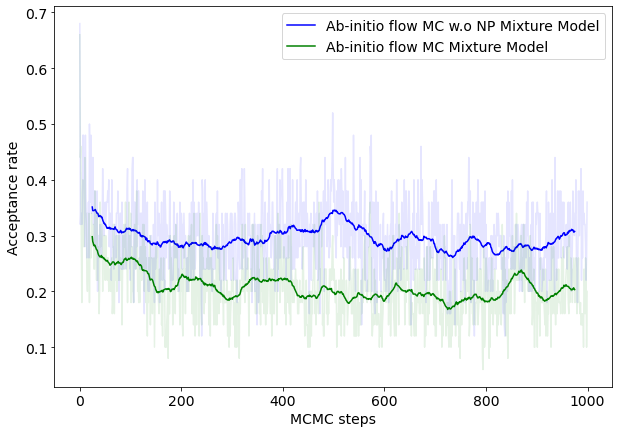

In [199]:
accs = {key: mcmcs[key]['accs'].float().mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], alpha=0.1, window_size=50, ax=ax, label=key, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

In [200]:
accs_window = {}

for key in accs.keys():
    accs_window[key] = dict(zip(list(range(0, 4)), accs[key].reshape(4, 250).reshape(4, -1) ))

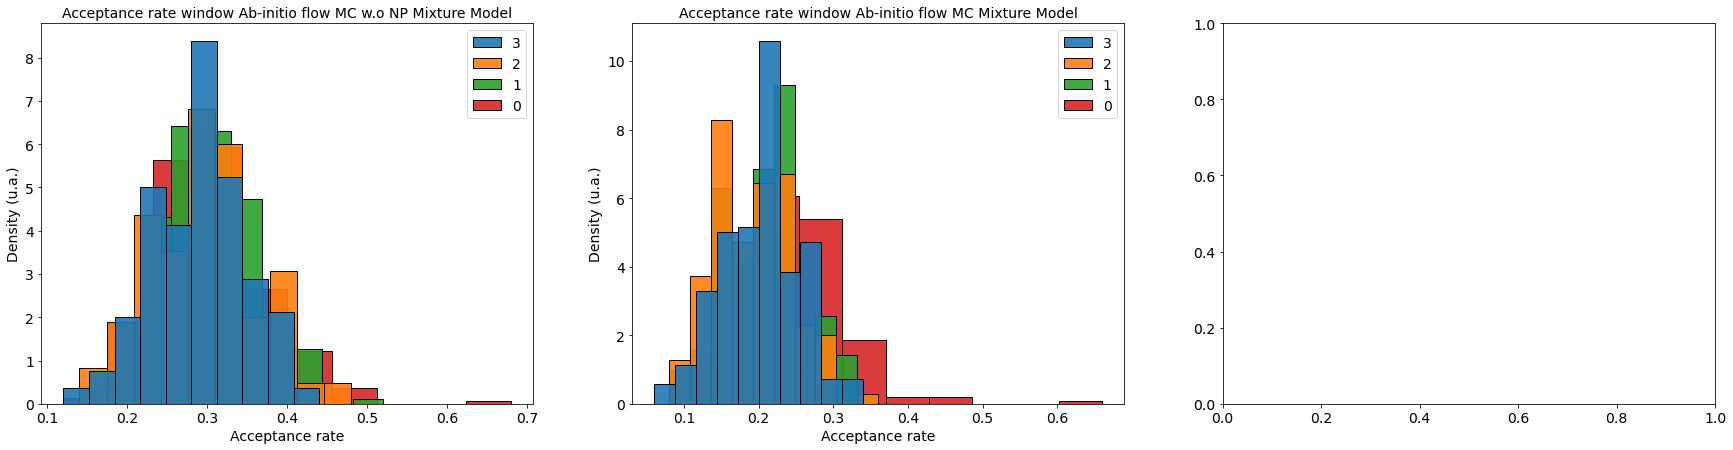

In [201]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

for i, key in enumerate(mcmcs.keys()):
    plot_energy_histogram(accs_window[key], ax=axs[i], bins=10, alpha=0.9, hue_order=list(range(0, 4))[::-1])
    
    axs[i].set_title('Acceptance rate window {:s}'.format(key))
    axs[i].set_xlabel('Acceptance rate')

# Energy review

(-6.95, -6.4)

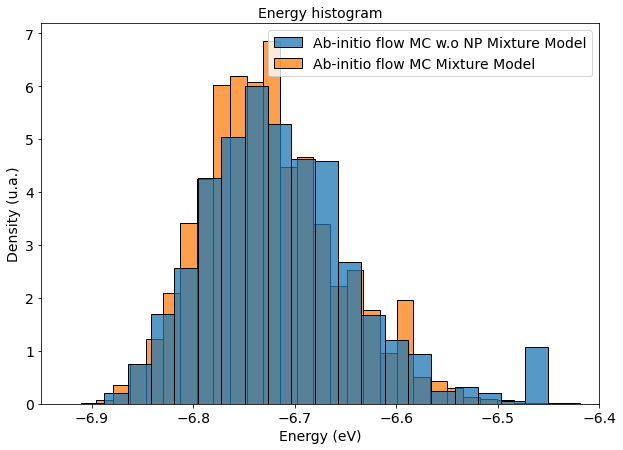

In [202]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.75)
axs.set_title(f'Energy histogram')

axs.set_xlim(-6.95, -6.4)

# Jumps

In [203]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

In [204]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

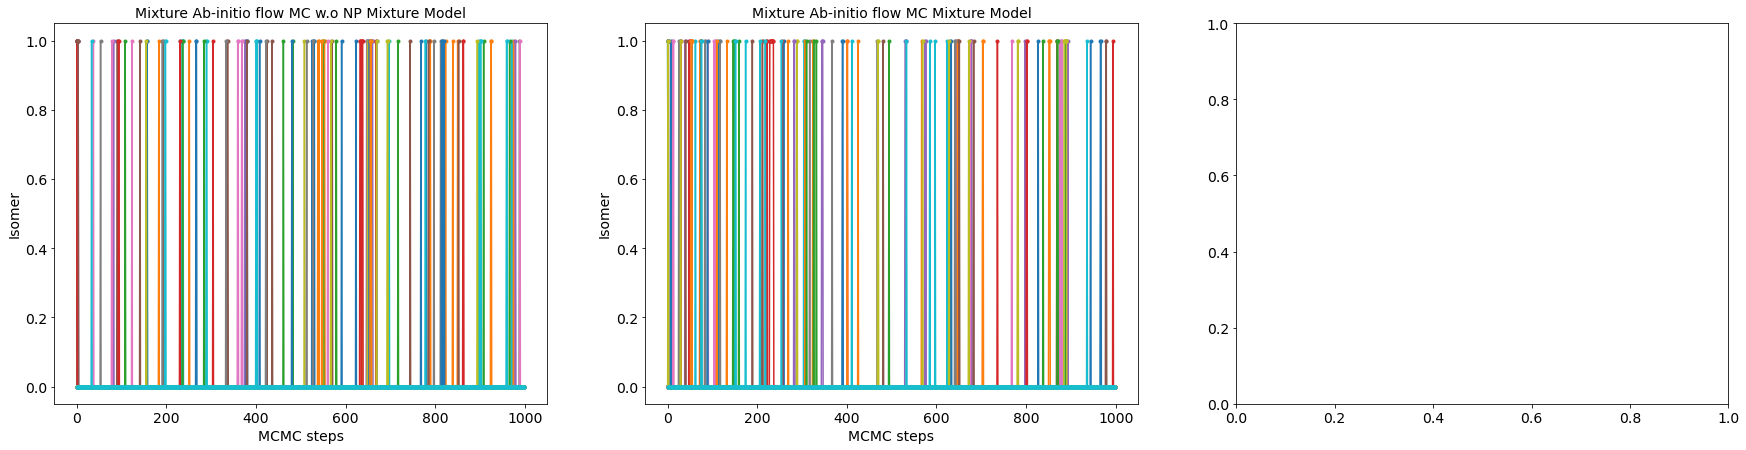

In [205]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

In [206]:
#jumps_consecutives = [len(isomers['Ab-initio flow MC w.o NP Mixture Model'][:, i].unique_consecutive(dim=0))-1 for i in range(50)]

In [207]:
#fig, ax = plt.
#ax.hist(jumps_consecutives, bins=5)

In [208]:
from flonacomldft.utils.diagnostics import R_hat
from flonacomldft.internal_coordinates import Coordinates_mapping

In [209]:
coord_mapping = Coordinates_mapping()

In [210]:
def get_zmat_from_real(xs, isomers, etype='dft'):

    xs = xs.clone().detach().numpy().transpose(1, 0, 2)
    isomers = isomers.clone().detach().numpy().transpose(1, 0)

    coord_mapping = Coordinates_mapping(etype=etype)

    zmat = torch.zeros(xs.shape)

    for i in range(xs.shape[1]):
        for j in range(xs.shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                        isomer=isomers[j, i])[0]
    zmat = zmat.clone().detach().numpy()

    return zmat

# $\hat{R} $ test

In [211]:
def plot_rhat(ax, rhat):

    ax.plot(rhat[1], rhat[0], '-o',  label=rhat[2])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

In [212]:
xs = {key: mcmcs[key]["xs"].detach() for key in mcmcs.keys()}

In [213]:
zmats = {key: get_zmat_from_real(xs[key], isomers[key]) for key in mcmcs.keys()}

rhat_s = {key: R_hat(zmats[key], n_split=10) for key in mcmcs.keys()}

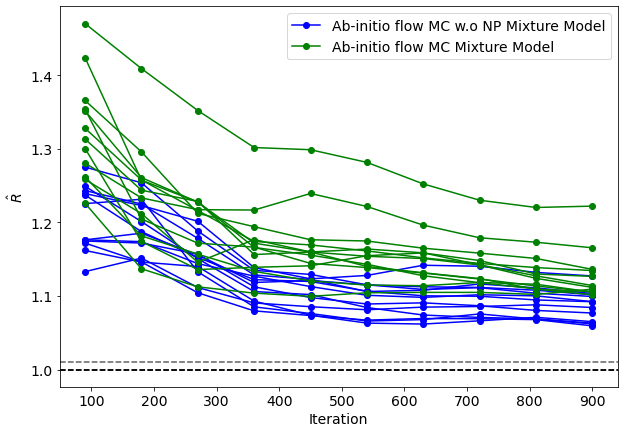

In [214]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for key in rhat_s.keys():
    ax.plot(rhat_s[key][1], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

# Populations

In [215]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

(0.0, 0.03)

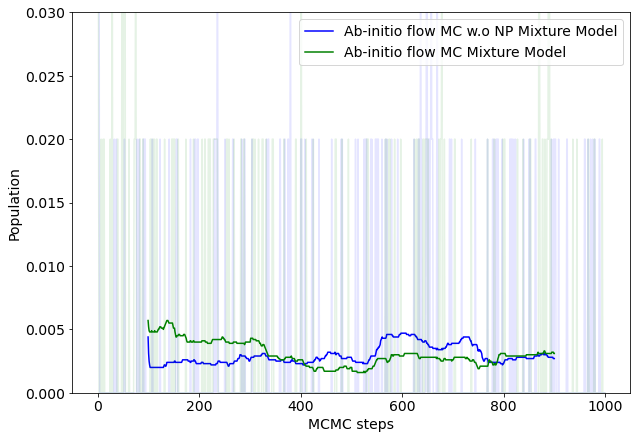

In [216]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in mcmcs.keys():
    set_plot_sequential_data(isomers[key].mean(dim=1).detach(), avg=True, window_size=200, ax=ax, label=key, color=color_keys[key], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

ax.set_ylim(0, 0.03)

In [ ]:
#from flonacomldft.utils.io_utils import get_project_path
#from flonacomldft.utils.plots import plot_energy_histogram

In [14]:
#isomer = 0
#n_id = 29941690
#project_path = get_project_path()
#results_folder = project_path + '/1-adaptive/results_adaptive_is{:d}_{:d}'.format(isomer, n_id)

In [15]:
#path_xs_proposals_save = 'xs_proposals_is{:d}_{:d}.csv'.format(isomer, n_id)
#xs_proposals = pd.read_csv(results_folder+'/'+path_xs_proposals_save)
#path_xs_proposals_comp = 'is{:d}_proposals_xs_{:d}.csv'.format(isomer, n_id)
#xs_proposals_comp = pd.read_csv(results_folder+'/'+path_xs_proposals_comp)

In [16]:
#xs_proposals.shape, xs_proposals_comp.shape

In [17]:
#energies_proposals = {
#    'file': xs_proposals['potential_energy'],#[50:1050],
#    'read': xs_proposals_comp['potential_energy'],#[0:1000],
#}

In [18]:
#plot_energy_histogram(energies_proposals)